In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

import torch
from torchvision import transforms

from data import DicomDataset
from src.brain_transforms import get_spatial_transform_list

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [15]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')
dataset = DicomDataset(data_dir)

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 71.00it/s]


In [25]:
aug_list = get_spatial_transform_list()
dataset.set_norm(norm_method = "min-max", mask_method="stack", masked_norm=True, perc_norm=0)
# dataset.set_aug(None)
dataset.set_aug(aug_list)


In [26]:
idx = 271

full = dataset[idx][0]

In [ ]:
# augs = transforms.Compose([
#         transforms.RandomHorizontalFlip(p=0.5),  
#         transforms.RandomVerticalFlip(p=0.5),    
#         transforms.RandomAffine(
#             degrees = 90,
#             translate = (0.2, 0.2),   # 20% percent in both directions
#             scale = (0.6, 1.4)        # 40% scale in either direction 
#         )

# ])


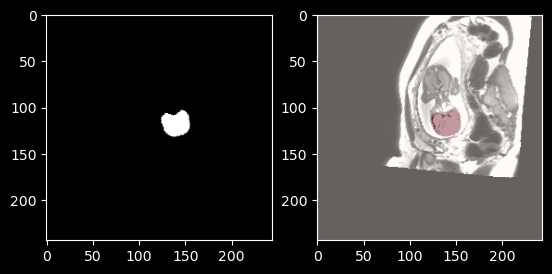

In [27]:
# full = augs(full)

mask = full[1]
scan = full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(mask, cmap='grey')
ax[1].imshow(scan, cmap="gray")
ax[1].imshow(mask, alpha=0.4, cmap="Reds")
